## KNN Models

Below we show how a KNN model handles and predicts our airbnb data, we have:
##### Model 1: No Scaling (69 features)
- Basic Train Test  
- Cross Validation  

##### Model 2: Scaled Features (69 features)
- Basic Train Test  
- Cross Validation  

##### Model 3: Lasso (alpha = 1) <- arbitrary larger alpha
- Basic Train Test (31 features removed)  
- Cross Validation (31 features removed) 

##### Model 4: Lasso (alpha = 0.035)
- Basic Train Test (17 features removed)  
- Cross Validation (17 features removed) 


##### Model 5:
- Julia's model here...

 ##### We used Lasso in model 2,3 and J, as a practical feature reduction tool to perform data engineering and address KNN's sensitivity to high-dimensional feature spaces. While Lasso's linear assumptions don't perfectly align with KNN's distance-based logic, it provides a reasonable, data-driven method for removing weak features,rather than relying on manual selection or arbitrary thresholds, which numerically improved KNN performance and error metrics significantly. The reduction in MSE, which will be seen in the results section, confirms that despite the spacial misalignment (linear and distance based), Lasso-based feature selection produced a dramatically better KNN model. It was a pragmatic engineering decision which produced good improvement. 

 ##### We also used 5 folds for our Cross Validation split of the dataset as a constant among all cross validation splits on the models because we are already varrying the features across the different models, but it definitely would be interesting to see how increasing the amount of folds to 8 or even 10 would average and affect the accuracy of the predictions of the models. 

### Model 1: No Scaling (Basic Train Test)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                   
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4),round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE","MAE", "MAPE"]).set_index("k")
print(f"\nModel 1 — All Features, No Scaling")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


(2580, 70) (645, 70) (2580,) (645,)

Model 1 — All Features, No Scaling

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.1928     8589.2       92.6779    58.53      0.53      
4      0.2165     8337.09      91.3076    58.16      0.53      
5      0.2214     8285.36      91.024     58.48      0.53      
7      0.2235     8263.2       90.9022    57.13      0.52      
9      0.2484     7997.8       89.4304    55.99      0.52      
11     0.248      8001.59      89.4516    55.91      0.52      


### Model 1: No Scaling (Cross Validation)

(2580, 70) (645, 70) (2580,) (645,)

Model 1 — All Features, No Scaling CV

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.2698     8615.61      92.8203      58.28        0.5372    
4      0.2701     8618.7       92.837       57.95        0.5375    
5      0.2521     8830.14      93.9688      58.04        0.5429    
7      0.2253     9148.49      95.6477      58.28        0.5488    
9      0.2325     9067.29      95.2223      57.62        0.5399    
11     0.2259     9143.67      95.6225      57.7         0.5402    


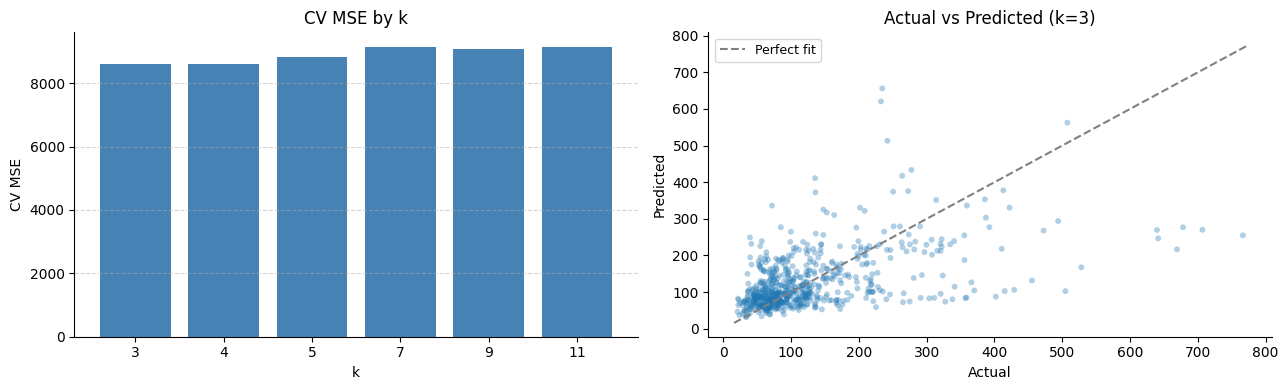

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train, y_train).predict(X_test)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 1 — All Features, No Scaling CV")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

### Model 2: With Scaling (Basic Train Test)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                        
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4), round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE","MAE", "MAPE"]).set_index("k")
print(f"\nModel 2 — All Features, Scaled")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")

(2580, 70) (645, 70) (2580,) (645,)

Model 2 — All Features, Scaled

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.6216     4026.63      63.4557    40.99      0.36      
4      0.6654     3560.9       59.6733    39.89      0.36      
5      0.6786     3420.04      58.4811    39.33      0.36      
7      0.7022     3168.88      56.2928    38.03      0.35      
9      0.7157     3024.93      54.9994    37.24      0.35      
11     0.7201     2978.95      54.5798    37.64      0.35      


### Model 2: With Scaling (Cross Validation)

(2580, 70) (645, 70) (2580,) (645,)

Model 2 CV — All Features, With Scaling

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.6639     3968.76      62.9981      41.06        0.3784    
4      0.6748     3843.61      61.9968      40.91        0.3776    
5      0.6833     3743.06      61.1805      40.44        0.3741    
7      0.7031     3513.41      59.274       39.19        0.3659    
9      0.7114     3415.15      58.4393      38.71        0.3627    
11     0.7045     3495.55      59.1232      39.47        0.3688    


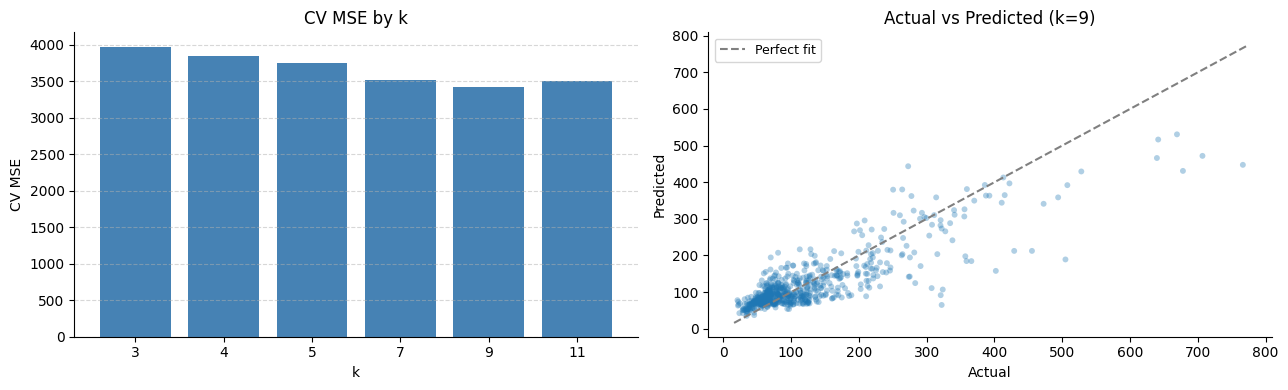

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'r2':   'r2',
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error'
    })
    cv_r2   =  cv_results['test_r2'].mean()
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 2 CV — All Features, With Scaling")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

### Model 3: Lasso (alpha = 1) (Basic Train Test)

Below is the initial calculation to retrieve the features to remove and fine tune the KNN model with Lasso when alpha = 1. 

In [5]:
import numpy as np
import pandas as pd
 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
 
df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()
 
X = df.drop('rate_avg', axis=1)
y = df['rate_avg']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
 
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
 
# Scaling features ( Since Lasso penalizes coefficients, features must be on same scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# Building and training the model
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
 
# Making predictions on the test set
y_pred = lasso.predict(X_test_scaled)
 
# Identify which features were zeroed out by Lasso
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lasso.coef_})
 
zeroed_features = coef_df[coef_df['coefficient'] == 0]
kept_features = coef_df[coef_df['coefficient'] != 0]
 
print(f"\nTotal features: {len(X.columns)}")
print(f"Features zeroed out by Lasso: {len(zeroed_features)}")
print(f"Features kept by Lasso: {len(kept_features)}")
 
print(f"\nZeroed out features:")
print(zeroed_features['feature'].tolist())


(2580, 70) (645, 70) (2580,) (645,)

Total features: 70
Features zeroed out by Lasso: 31
Features kept by Lasso: 39

Zeroed out features:
['rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_value', 'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room', 'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events', 'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may', 'is_november', 'is_october', 'has_gym', 'listing_type_Entire house', 'listing_type_Private room in bungalow', 'listing_type_Private room in cottage', 'listing_type_Private room in home', 'listing_type_Private room in loft', 'room_type_private_room', 'cancellation_policy_Super Strict 30 Days']


### The features found above are now going to be removed from the initial data set, and tested below for both basic train test as well as cross validation.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop(['rate_avg', 'rating_overall', 'rating_accuracy', 'rating_checkin',
             'rating_cleanliness', 'rating_communication', 'rating_value',
             'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events',
             'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may',
             'is_november', 'is_october', 'has_gym', 'listing_type_Entire house',
             'listing_type_Private room in bungalow', 'listing_type_Private room in cottage',
             'listing_type_Private room in home', 'listing_type_Private room in loft',
             'room_type_private_room', 'cancellation_policy_Super Strict 30 Days'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                         
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4), round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE", "MAE", "MAPE"]).set_index("k")
print(f"\nModel 3 — Lasso (α=1.0) Feature Selection (39 features)")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


(2580, 39) (645, 39) (2580,) (645,)

Model 3 — Lasso (α=1.0) Feature Selection (39 features)

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.8888     1183.45      34.4012    20.01      0.17      
4      0.8995     1069.31      32.7003    19.87      0.17      
5      0.8925     1144.28      33.8272    20.94      0.18      
7      0.866      1425.46      37.7553    23.98      0.2       
9      0.8485     1612.16      40.1517    25.32      0.22      
11     0.8256     1856.23      43.084     27.63      0.24      


### Model 3: Lasso (alpha = 1) (Cross Validation)

(2580, 39) (645, 39) (2580,) (645,)

Model 3 — Lasso (α=1.0) Feature Selection (39 features)

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.8957     1230.98      35.0853      20.76        0.1846    
4      0.8905     1291.34      35.9353      22.16        0.1985    
5      0.8847     1360.64      36.8868      23.18        0.2093    
7      0.8656     1589.09      39.8634      25.74        0.2366    
9      0.8492     1783.25      42.2286      27.53        0.2551    
11     0.833      1974.36      44.4338      29.33        0.2724    


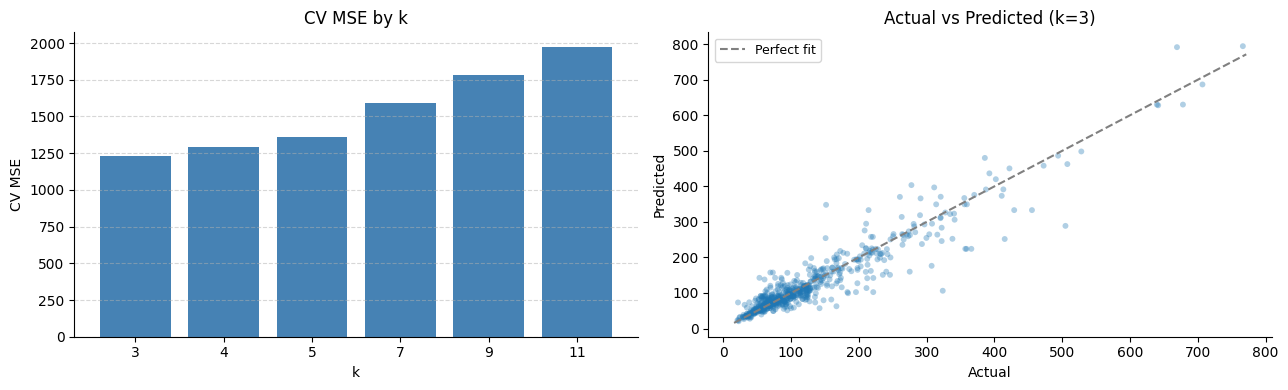

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop(['rate_avg', 'rating_overall', 'rating_accuracy', 'rating_checkin',
             'rating_cleanliness', 'rating_communication', 'rating_value',
             'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events',
             'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may',
             'is_november', 'is_october', 'has_gym', 'listing_type_Entire house',
             'listing_type_Private room in bungalow', 'listing_type_Private room in cottage',
             'listing_type_Private room in home', 'listing_type_Private room in loft',
             'room_type_private_room', 'cancellation_policy_Super Strict 30 Days'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 3 — Lasso (α=1.0) Feature Selection (39 features)")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

### Model 4: Lasso (alpha = 0.035) (Basic Train Test)

This optimal alpha of 0.035 for our dataset, and the subsequent features to be removed by Lasso are referenced from the findings of the regression model and used here for reasonable feature removal, since KNN for regression is better suited for a reduced amount of features. 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop(['rate_avg', 'Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays',
             'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_june',
             'is_november', 'is_september', 'listing_type_Private room in bungalow',
             'listing_type_Private room in home', 'listing_type_Private room in loft'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                          
    mape = np.mean(np.abs((y_test - y_pred) / y_test))

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4),round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE", "MAE", "MAPE"]).set_index("k")
print(f"\nModel 4 — Optimal Lasso (α=0.035) Feature Selection (53 features)")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


(2580, 53) (645, 53) (2580,) (645,)

Model 4 — Optimal Lasso (α=0.035) Feature Selection (53 features)

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.8591     1499.27      38.7204    23.64      0.2       
4      0.8531     1563.09      39.536     24.63      0.21      
5      0.8442     1658.03      40.7189    25.31      0.21      
7      0.8441     1659.47      40.7366    26.07      0.23      
9      0.8255     1856.54      43.0876    27.34      0.24      
11     0.8087     2035.29      45.1142    28.8       0.25      


### Model 4: Lasso (alpha = 0.035) (Cross Validation)

(2580, 53) (645, 53) (2580,) (645,)

Model 4 — Optimal Lasso (α=0.035) Feature Selection - CV

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.8615     1633.0       40.4105      25.02        0.2258    
4      0.8701     1535.9       39.1905      24.88        0.2274    
5      0.8668     1574.12      39.6752      25.29        0.2327    
7      0.8525     1744.65      41.769       26.91        0.2488    
9      0.8441     1842.66      42.9262      28.23        0.2642    
11     0.8289     2021.54      44.9616      29.62        0.278     


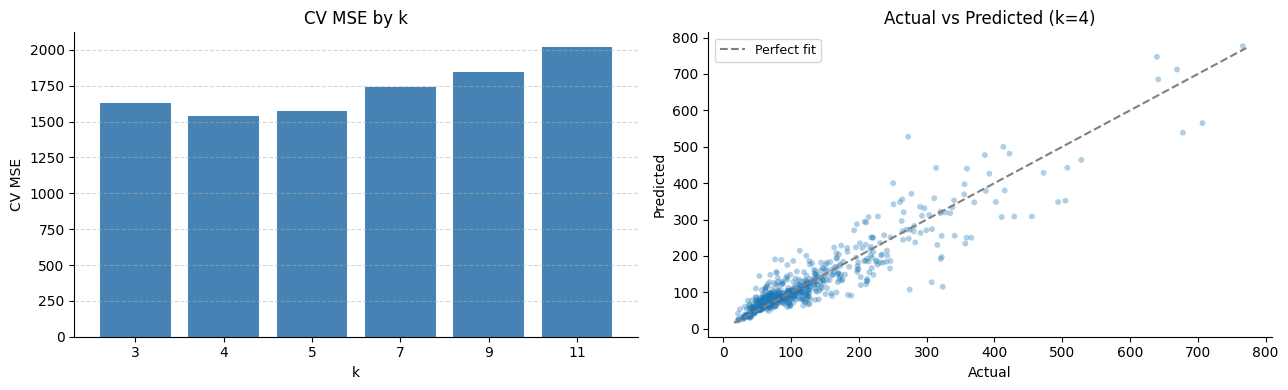

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv')
df.head()

X = df.drop(['rate_avg', 'Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays',
             'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_june',
             'is_november', 'is_september', 'listing_type_Private room in bungalow',
             'listing_type_Private room in home', 'listing_type_Private room in loft'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 4 — Optimal Lasso (α=0.035) Feature Selection - CV")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

## Result Comparison

In [10]:
import pandas as pd
import numpy as np

models = ['M1 No Scaling', 'M1 No Scaling (CV)',
          'M2 Scaled', 'M2 Scaled (CV)',
          'M4 Lasso α=0.035', 'M4 Lasso α=0.035 (CV)',
          'M3 Lasso α=1.0', 'M3 Lasso α=1.0 (CV)']

best_mse = [8001.59, 8615.61, 2978.95, 3415.10, 1499.27, 1535.90, 1069.31, 1230.98]

df_mse  = pd.DataFrame({'Model': models,
                        'Best k (MSE)':  [11,9,11,3,3,4,4,3],
                        'Best MSE':      best_mse})

df_rmse = pd.DataFrame({'Model': models,
                        'Best k (RMSE)': [11,9,11,3,3,4,4,3],
                        'Best RMSE':     [round(np.sqrt(v), 4) for v in best_mse]})

df_r2   = pd.DataFrame({'Model': models,
                        'Best k (R²)':  [9,9,11,4,3,4,4,3],
                        'Best R²':      [0.2484,0.2701,0.7201,0.7114,0.8591,0.8701,0.8995,0.8957]})

df_mae  = pd.DataFrame({'Model': models,
                        'Best k (MAE)': [11,11,11,9,3,4,4,3],
                        'Best MAE':     [55.91,57.70,37.64,37.24,23.64,24.88,19.87,20.76]})

df_mape = pd.DataFrame({'Model': models,
                        'Best k (MAPE)': [9,9,11,9,3,4,3,3],
                        'Best MAPE':     [0.52,0.5399,0.35,0.35,0.20,0.2258,0.17,0.1846]})

combined = (df_mse
            .merge(df_rmse, on='Model')
            .merge(df_r2,   on='Model')
            .merge(df_mae,  on='Model')
            .merge(df_mape, on='Model'))

combined = combined[['Model',
                     'Best k (MSE)',  'Best MSE',
                     'Best k (RMSE)', 'Best RMSE',
                     'Best k (R²)',   'Best R²',
                     'Best k (MAE)',  'Best MAE',
                     'Best k (MAPE)', 'Best MAPE']]

print(combined.to_string(index=False))

                Model  Best k (MSE)  Best MSE  Best k (RMSE)  Best RMSE  Best k (R²)  Best R²  Best k (MAE)  Best MAE  Best k (MAPE)  Best MAPE
        M1 No Scaling            11   8001.59             11    89.4516            9   0.2484            11     55.91              9     0.5200
   M1 No Scaling (CV)             9   8615.61              9    92.8203            9   0.2701            11     57.70              9     0.5399
            M2 Scaled            11   2978.95             11    54.5798           11   0.7201            11     37.64             11     0.3500
       M2 Scaled (CV)             3   3415.10              3    58.4389            4   0.7114             9     37.24              9     0.3500
     M4 Lasso α=0.035             3   1499.27              3    38.7204            3   0.8591             3     23.64              3     0.2000
M4 Lasso α=0.035 (CV)             4   1535.90              4    39.1906            4   0.8701             4     24.88              4    

#### From the results of the KNN models we can see that:

### 1. Scaling makes a significant difference: The jump from Model 1 (no scaling and MSE of around 8000) to Model 2 (scaled and MSE of around 3000) is due to KNN's reliance on distance calculations to average neighbours and predict prices, where unscaled features with large ranges overpower the distance metric and produce inaccurate predictions. Scaling fixed that and normalizes all features so that larger ranges don't necessarily equate to greater influence. 

### 2. Feature selection is a significant driver of performance: Models 3 and 4 created with lasso feature selection, dramatically outperform Models 1 and 2 across all metric. Model 3 (with Lasso α = 1.0, 39 features) achieves the best MSE of 1069 and R² of 0.8995, meaning the model explains around 90% of the variance in Airbnb nightly price. Removing irrelevant features helped KNN find more meaningful neighbours. Model 4 used a Lasso with α=0.035 and 53 features, and performed slightly worse than Model 3 across all metrics. This suggests the extra 14 features it retained were noisy rather than informative, and the less features we have in the KNN model the better. Additionally, it also proves that a majority of our features seemed to be producing uneccessary noise rather than contributing to the target value in any significant way. In the Tree Based Model section we will see exactly which features contribute the most to the target value, and the amount of features, or lack there of, that do, is a little jarring. The fact that Lasso reduction with an alpha value of 1 outperforms lasso reduction using the optimal alpha of 0.035 means that for a KNN model, feature noise is more damaging than feature loss, and it seems our dataset had a significant amount of feature loss. I predict that if I had further tested an even larger alpha value and been even more strict with features that Lasso reduces, that would also positively affect the performance of the KNN model because of the fact that a majority of our features seem to be noise. 

### 3. CV vs Test Train results: The CV and Test Train variants of each model produce very similar metrics, meaning our models are not overfitting to the training data. CV MSE is slightly higher than Train Test MSE because a cross validation averages performance across 5 different train/test splits rather than a single split, and is therefore a more honest estimate of how the model will perform on unseen data.

## Best overall model: Model 3 (Basic Train Test), k=4: With an MSE of 1069, RMSE of 32.7, R² 0.8995, and MAE 19.87, this model predicts Airbnb nightly price within about $20 on average. Given the range of Airbnb prices, that's a strong result for a KNN model.
